In [1]:
# use float64'
from jax import config
config.update("jax_enable_x64", True)

In [2]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import jaxley as jx
from jaxley.channels import HH
import numpy as np
from matplotlib.patches import Circle, Rectangle
from mpl_toolkits.axisartist import Subplot

plt.style.use("../.matplotlibrc")

In [3]:
comp = jx.Compartment()
comp.insert(HH())
comp.set("v", -65.0)
comp.init_states()

dt = 0.025
tmax = 40
ts = jnp.arange(0, tmax, dt)
ipt = jx.step_current(5, 30, 0.01, dt, ts[-1])
comp.stimulate(ipt)

comp.record("v")
comp.record("HH_m")
comp.record("HH_h")
comp.record("HH_n")

u = jx.integrate(comp, t_max=tmax, delta_t=dt)[:, 1:]
v = u[0]

ts_data = jnp.arange(0, tmax, 1.0)
v_data = jnp.interp(ts_data, ts, v)
v_data = v_data + 3.0 * jr.normal(jr.PRNGKey(0), v_data.shape)  # add noise

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.


In [4]:
def setup_arrow_axes(ax, xlabel, ylabel='', xrot=0, yrot=0, xlabelpad=0, ylabelpad=0):
    for direction in ["bottom", "left"]:
        ax.axis[direction].set_axisline_style("-|>")
        ax.axis[direction].set_visible(True)
        ax.axis[direction].major_ticks.set_tick_out(False)
        ax.axis[direction].major_ticks.set_visible(False)
        ax.axis[direction].line.set_color('black')
        ax.axis[direction].line.set_mutation_scale(25)
    for direction in ["right", "top"]:
        ax.axis[direction].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis["bottom"].label.set_text(xlabel)
    ax.axis["bottom"].label.set_visible(True)
    ax.axis["bottom"].label.set_pad(xlabelpad)
    ax.axis["bottom"].label.set_rotation(xrot)

    ax.axis["left"].label.set_text(ylabel)
    ax.axis["left"].label.set_visible(True)
    ax.axis["left"].label.set_pad(ylabelpad)  # manually shift left relative to axis
    ax.axis["left"].label.set_rotation(yrot)

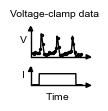

In [17]:

fig = plt.figure(figsize=(0.8, 1.0), layout="constrained")
gs = fig.add_gridspec(2, 1, height_ratios=[2, 1])

# Create Subplot axes
ax0 = Subplot(fig, gs[0, 0])
ax1 = Subplot(fig, gs[1, 0], sharex=ax0)
fig.add_subplot(ax0)
fig.add_subplot(ax1)
ax = [ax0, ax1]

ax[0].scatter(ts_data, v_data, color="grey", edgecolors="black", s=2)
ax[0].plot(ts, v, color="k")

ax[1].plot(ts, ipt, color="k", label="True")

fig.suptitle(r"Voltage-clamp data")

setup_arrow_axes(ax[0], xlabel="", ylabel=r"$V$", ylabelpad=2, yrot=90)
setup_arrow_axes(ax[1], xlabel=r"$Time$", ylabel=r"$I$", ylabelpad=2, yrot=90)

plt.savefig("../figures/paper/fig1/voltage_clamp.svg", transparent=True, bbox_inches='tight')

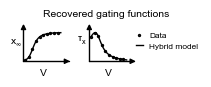

In [71]:
v_range = jnp.linspace(-100.0, 100.0, 100)
a_m, b_m = HH.m_gate(v_range)
tau_m = 1.0 / (a_m + b_m)
m_inf = a_m * tau_m

a_h, b_h = HH.h_gate(v_range)
tau_h = 1.0 / (a_h + b_h)
h_inf = a_h * tau_h

a_n, b_n = HH.n_gate(v_range)
tau_n = 1.0 / (a_n + b_n)
n_inf = a_n * tau_n

fig = plt.figure(figsize=(2.0, 0.6), layout="constrained")
gs = fig.add_gridspec(1, 2)

ax0 = Subplot(fig, gs[0, 0])
ax1 = Subplot(fig, gs[0, 1])
fig.add_subplot(ax0)
fig.add_subplot(ax1)
ax = [ax0, ax1]

ax[0].scatter(v_range[::10], n_inf[::10], color="grey", edgecolors="black", s=2)
ax[0].plot(v_range, n_inf, color="k")

s = ax[1].scatter(
    v_range[::10], tau_n[::10], color="grey", edgecolors="black", label="Data", s=2
)
l, = ax[1].plot(v_range, tau_n, color="k", label="Hybrid model")

ax[1].legend(
    handles=[s, l],
    loc="center left",
    bbox_to_anchor=(1.0, 0.7),
    frameon=False,
    handlelength=0.8,
    fontsize=6,
)

fig.suptitle(r"Recovered gating functions", y=1.2)

setup_arrow_axes(ax[0], xlabel=r"$V$", ylabel=r"$x_{\infty}$", yrot=90, ylabelpad=2)
setup_arrow_axes(ax[1], xlabel=r"$V$", ylabel=r"$\tau_x$", yrot=90, ylabelpad=2)

plt.savefig("../figures/paper/fig1/gates.svg", transparent=True, bbox_inches='tight')

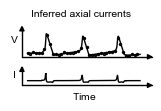

In [5]:

fig = plt.figure(figsize=(1.5, 1.0), layout="constrained")
gs = fig.add_gridspec(2, 1, height_ratios=[2, 1])

# Create Subplot axes
ax0 = Subplot(fig, gs[0, 0])
ax1 = Subplot(fig, gs[1, 0], sharex=ax0)
fig.add_subplot(ax0)
fig.add_subplot(ax1)
ax = [ax0, ax1]

ax[0].scatter(ts_data, v_data, color="grey", edgecolors="black", s=2, label="Data")
ax[0].plot(ts, v, color="k", label="Hybrid model")

# ax[0].legend(
#     loc="center left",
#     bbox_to_anchor=(1.0, 0.5),
#     frameon=False,
#     handlelength=0.8,
# )


kernel = jnp.array([5.0, 0.0, -5.0])
axial_ipt = 2.0 * jnp.convolve(v, kernel, mode="same")
ax[1].plot(ts[1:-1], axial_ipt[1:-1], color="k", label="axial current")
ax[1].set_ylim(-80, 130)


fig.suptitle(r"Inferred axial currents")

setup_arrow_axes(ax[0], xlabel="", ylabel=r"$V$", ylabelpad=2, yrot=90)
setup_arrow_axes(ax[1], xlabel=r"$Time$", ylabel=r"$I$", ylabelpad=2, yrot=90)




plt.savefig("../figures/paper/fig1/axial_current.svg", transparent=True, bbox_inches='tight')


In [21]:
comp = jx.Compartment()
comp.insert(HH())
comp.set("v", -65.0)
comp.init_states()

dt = 0.025
tmax = 80
ts_long = jnp.arange(0, tmax+dt, dt)
ipt_gen = jx.step_current(50, 25, 0.005, dt, ts_long[-1])
ipt_long = ipt_gen.at[ts_long < 40].set(ipt)
comp.stimulate(ipt_long)

comp.record("v")
comp.record("HH_m")
comp.record("HH_h")
comp.record("HH_n")

u_long = jx.integrate(comp, t_max=tmax, delta_t=dt)
v_long = u_long[0]

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.


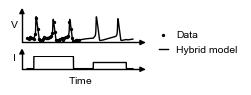

In [ ]:
fig = plt.figure(figsize=(1.5, 0.7))
gs = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0.65)

ax0 = Subplot(fig, gs[0])
ax1 = Subplot(fig, gs[1])
fig.add_subplot(ax0)
fig.add_subplot(ax1)
ax = [ax0, ax1]

ax[0].scatter(ts_data, v_data, color="grey", edgecolors="black", s=2, label="Data")
ax[0].plot(ts_long, v_long, color="k", label="Hybrid model")

ax[1].plot(ts_long, ipt_long, color="k", label="Hybrid model")

ax[0].legend(
    loc="center left",
    bbox_to_anchor=(1.1, 0.0),
    frameon=False,
    handlelength=0.8,
)

setup_arrow_axes(ax[0], xlabel="", ylabel=r"$V$", yrot=90, ylabelpad=2)
setup_arrow_axes(ax[1], xlabel=r"$Time$", ylabel=r"$I$", yrot=90, ylabelpad=2)

plt.savefig("../figures/paper/fig1/generalization.svg", transparent=True, bbox_inches='tight')


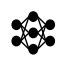

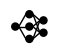

In [110]:
def plot_network(ax, layer_sizes, node_color, pos=(0, 0), x_spacing=1.0, y_spacing=0.5, neuron_radius=0.2, y_center=1.5):
    n_layers = len(layer_sizes)
    x_offset, y_offset = pos
    x_locs = np.linspace(0, x_spacing * (n_layers - 1), n_layers) + x_offset
    
    for layer_idx in range(n_layers - 1):
        current_size = layer_sizes[layer_idx]
        next_size = layer_sizes[layer_idx + 1]
        x1, x2 = x_locs[layer_idx], x_locs[layer_idx + 1]
        y1s = [y_center - ((current_size - 1) * y_spacing) / 2 + i * y_spacing + y_offset for i in range(current_size)]
        y2s = [y_center - ((next_size - 1) * y_spacing) / 2 + i * y_spacing + y_offset for i in range(next_size)]
        
        for i, y1 in enumerate(y1s):
            for j, y2 in enumerate(y2s):
                ax.plot([x1 + neuron_radius, x2 - neuron_radius], [y1, y2],
                        'k-', zorder=1)

    # Draw nodes
    for layer_idx, size in enumerate(layer_sizes):
        x = x_locs[layer_idx]
        y0 = y_center - ((size - 1) * y_spacing) / 2 + y_offset
        for i in range(size):
            y = y0 + i * y_spacing
            circ = Circle((x, y), neuron_radius, facecolor=node_color,
                          edgecolor='black', zorder=2)
            ax.add_patch(circ)


# Network 1
layer_sizes = [2, 3, 2]   # network architecture (input, hidden, output)
fig, ax = plt.subplots(figsize=(0.6, 0.6))
ax.axis('off')
plot_network(ax, layer_sizes, plt.cm.Grays(1.0), pos=(0, 0), x_spacing=0.8, y_spacing=0.7)
plt.savefig("../figures/paper/fig1/net.svg", transparent=True, bbox_inches='tight')

fig, ax = plt.subplots(figsize=(0.5, 0.5))
layer_sizes = [1, 3, 2]   # network architecture (input, hidden, output)
ax.axis('off')
plot_network(ax, layer_sizes, plt.cm.Grays(1.0), pos=(1.8, -1.5), x_spacing=0.8, y_spacing=0.7)
ax.set_aspect("equal")
plt.savefig("../figures/paper/fig1/node.svg", transparent=True, bbox_inches='tight')

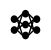

In [5]:
def plot_network(ax, layer_sizes, node_color, pos=(0, 0), x_spacing=1.0, y_spacing=0.5, neuron_radius=0.2, y_center=1.5):
    n_layers = len(layer_sizes)
    x_offset, y_offset = pos
    x_locs = np.linspace(0, x_spacing * (n_layers - 1), n_layers) + x_offset
    
    for layer_idx in range(n_layers - 1):
        current_size = layer_sizes[layer_idx]
        next_size = layer_sizes[layer_idx + 1]
        x1, x2 = x_locs[layer_idx], x_locs[layer_idx + 1]
        y1s = [y_center - ((current_size - 1) * y_spacing) / 2 + i * y_spacing + y_offset for i in range(current_size)]
        y2s = [y_center - ((next_size - 1) * y_spacing) / 2 + i * y_spacing + y_offset for i in range(next_size)]
        
        for i, y1 in enumerate(y1s):
            for j, y2 in enumerate(y2s):
                ax.plot([x1 + neuron_radius, x2 - neuron_radius], [y1, y2],
                        'k-', zorder=1)

    # Draw nodes
    for layer_idx, size in enumerate(layer_sizes):
        x = x_locs[layer_idx]
        y0 = y_center - ((size - 1) * y_spacing) / 2 + y_offset
        for i in range(size):
            y = y0 + i * y_spacing
            circ = Circle((x, y), neuron_radius, facecolor=node_color,
                          edgecolor='black', zorder=2)
            ax.add_patch(circ)


# Network 1
layer_sizes = [2, 3, 2]   # network architecture (input, hidden, output)
fig, ax = plt.subplots(figsize=(0.4, 0.4))
ax.axis('off')
plot_network(ax, layer_sizes, plt.cm.Grays(1.0), pos=(0, 0), x_spacing=0.8, y_spacing=0.7)
plt.savefig("../figures/paper/fig1/net.svg", transparent=True, bbox_inches='tight')

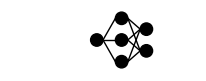

In [8]:
# Network 1
layer_sizes = [1, 3, 2]   # network architecture (input, hidden, output)
fig, ax = plt.subplots(figsize=(2.4, 2.4))
ax.axis('off')
plot_network(ax, layer_sizes, plt.cm.Grays(1.0), pos=(1.8, -1.5), x_spacing=0.8, y_spacing=0.7)
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 1)
ax.set_aspect("equal")

plt.savefig("../figures/paper/fig1/multi_comp_net.svg", transparent=True, bbox_inches='tight')